In [1]:
# Cell 1 - Imports and global settings

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.options.display.float_format = "{:,.4f}".format
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

BASE_DIR = Path("/Users/tonytony/Final Project")
DATA_PATH = BASE_DIR / "Data" / "Cleaned" / "panel_with_event_dummies_and_extra_drivers.csv"
OUTPUT_DIR = BASE_DIR / "Data" / "Cleaned"

TRAIN_END_YEAR = 2017
VALID_START_YEAR = 2016
TEST_START_YEAR = 2018
TEST_END_YEAR = 2022

TARGET_COL = "target_log_gdp_next_year"

ALPHA_GRID = [0.0005, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0]
L1_RATIO_GRID = [0.1, 0.3, 0.5, 0.7, 0.9]

print("Base dir:", BASE_DIR)
print("Data path:", DATA_PATH)
print("Output dir:", OUTPUT_DIR)

Base dir: /Users/tonytony/Final Project
Data path: /Users/tonytony/Final Project/Data/Cleaned/panel_with_event_dummies_and_extra_drivers.csv
Output dir: /Users/tonytony/Final Project/Data/Cleaned


In [2]:
# Cell 2 - Shared helpers

def regression_metrics(actual, predicted):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)

    mae = np.mean(np.abs(actual - predicted))
    rmse = np.sqrt(np.mean((actual - predicted) ** 2))

    nonzero_mask = actual != 0
    if nonzero_mask.any():
        mape = np.mean(
            np.abs((actual[nonzero_mask] - predicted[nonzero_mask]) / actual[nonzero_mask])
        ) * 100
    else:
        mape = np.nan

    sst = np.sum((actual - actual.mean()) ** 2)
    sse = np.sum((actual - predicted) ** 2)
    r2 = 1 - (sse / sst) if sst > 0 else np.nan

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE_pct": mape,
        "R_squared": r2,
    }


def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def sanitize_feature_name(name):
    name = str(name)
    name = name.replace("num__", "")
    name = name.replace("cat__", "")
    return name


def build_pipeline(numeric_features, categorical_features, alpha, l1_ratio):
    transformers = []

    if numeric_features:
        transformers.append(
            ("num", StandardScaler(), numeric_features)
        )

    if categorical_features:
        transformers.append(
            ("cat", make_one_hot_encoder(), categorical_features)
        )

    preprocessor = ColumnTransformer(
        transformers=transformers,
        remainder="drop"
    )

    model = ElasticNet(
        alpha=alpha,
        l1_ratio=l1_ratio,
        fit_intercept=True,
        max_iter=50000,
        random_state=42,
        selection="cyclic"
    )

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model),
        ]
    )
    return pipeline


def build_prediction_frame(pipeline, df, model_name, model_family, model_note, alpha, l1_ratio):
    pred_df = df.copy()

    pred_df["model"] = model_name
    pred_df["model_family"] = model_family
    pred_df["model_note"] = model_note
    pred_df["alpha"] = alpha
    pred_df["l1_ratio"] = l1_ratio

    pred_df["predicted_log_gdp_next_year"] = pipeline.predict(pred_df)
    pred_df["actual_log_gdp_next_year"] = pred_df[TARGET_COL]

    pred_df["predicted_gdp_next_year"] = np.exp(pred_df["predicted_log_gdp_next_year"])
    pred_df["actual_gdp_next_year"] = np.exp(pred_df["actual_log_gdp_next_year"])

    pred_df["feature_year"] = pred_df["year"].astype(int)
    pred_df["target_year"] = pred_df["feature_year"] + 1

    pred_df["absolute_error_usd"] = np.abs(
        pred_df["actual_gdp_next_year"] - pred_df["predicted_gdp_next_year"]
    )
    pred_df["absolute_percentage_error_pct"] = (
        pred_df["absolute_error_usd"] / pred_df["actual_gdp_next_year"]
    ) * 100
    pred_df["signed_percentage_error_pct"] = (
        (pred_df["predicted_gdp_next_year"] - pred_df["actual_gdp_next_year"])
        / pred_df["actual_gdp_next_year"]
    ) * 100

    return pred_df


def build_yearly_summary(pred_df):
    rows = []
    for target_year, year_df in pred_df.groupby("target_year"):
        rows.append(
            {
                "target_year": int(target_year),
                "n_obs": len(year_df),
                "actual_mean_gdp": year_df["actual_gdp_next_year"].mean(),
                "predicted_mean_gdp": year_df["predicted_gdp_next_year"].mean(),
                "pred_to_actual_ratio": (
                    year_df["predicted_gdp_next_year"].mean()
                    / year_df["actual_gdp_next_year"].mean()
                ),
                "mean_absolute_percentage_error_pct": year_df[
                    "absolute_percentage_error_pct"
                ].mean(),
            }
        )
    return pd.DataFrame(rows).sort_values("target_year").reset_index(drop=True)


def build_region_metrics(pred_df):
    rows = []
    for region_name, region_df in pred_df.groupby("wb_region"):
        rows.append(
            {
                "wb_region": region_name,
                "n_obs": len(region_df),
                **regression_metrics(
                    actual=region_df["actual_gdp_next_year"],
                    predicted=region_df["predicted_gdp_next_year"],
                ),
            }
        )
    return pd.DataFrame(rows).sort_values("RMSE").reset_index(drop=True)


def coefficient_table(pipeline):
    feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()
    feature_names = [sanitize_feature_name(x) for x in feature_names]

    coefficients = pipeline.named_steps["model"].coef_

    coef_df = pd.DataFrame(
        {
            "term": feature_names,
            "coefficient": coefficients,
            "abs_coefficient": np.abs(coefficients),
        }
    ).sort_values("abs_coefficient", ascending=False).reset_index(drop=True)

    return coef_df


def show_or_close_plot():
    if "ipykernel" in sys.modules:
        plt.show()
    else:
        plt.close()


def run_elastic_net_spec(
    model_name,
    model_family,
    model_note,
    output_prefix,
    usecols,
    numeric_features,
    categorical_features=None,
    make_year_trend=False,
):
    if categorical_features is None:
        categorical_features = []

    meta_cols = [
        "country_name",
        "country_code",
        "wb_region",
        "year",
        "gdp_per_capita_usd",
        TARGET_COL,
    ]

    all_usecols = list(dict.fromkeys(meta_cols + usecols))

    panel_df = pd.read_csv(DATA_PATH, usecols=all_usecols)
    model_df = panel_df.copy()

    for col in all_usecols:
        if col not in ["country_name", "country_code", "wb_region"]:
            model_df[col] = pd.to_numeric(model_df[col], errors="coerce")

    model_df = model_df.dropna().copy()
    model_df["country_name"] = model_df["country_name"].astype(str)
    model_df["country_code"] = model_df["country_code"].astype(str)
    model_df["wb_region"] = model_df["wb_region"].astype(str)
    model_df["year"] = model_df["year"].astype(int)

    if make_year_trend:
        model_df["year_trend"] = model_df["year"] - model_df["year"].min()

    feature_cols = numeric_features + categorical_features
    model_df = model_df.dropna(subset=feature_cols + [TARGET_COL]).copy()

    train_full_df = model_df[model_df["year"] <= TRAIN_END_YEAR].copy()
    train_core_df = model_df[model_df["year"] < VALID_START_YEAR].copy()
    valid_df = model_df[
        (model_df["year"] >= VALID_START_YEAR) & (model_df["year"] <= TRAIN_END_YEAR)
    ].copy()
    test_df = model_df[
        (model_df["year"] >= TEST_START_YEAR) & (model_df["year"] <= TEST_END_YEAR)
    ].copy()

    print("=" * 100)
    print(model_name)
    print("Sample shape:", model_df.shape)
    print("Train core rows:", len(train_core_df))
    print("Validation rows:", len(valid_df))
    print("Train full rows:", len(train_full_df))
    print("Test rows:", len(test_df))
    print(
        "Test target years:",
        int((test_df["year"] + 1).min()),
        "-",
        int((test_df["year"] + 1).max()),
    )

    validation_rows = []
    for alpha in ALPHA_GRID:
        for l1_ratio in L1_RATIO_GRID:
            pipeline = build_pipeline(
                numeric_features=numeric_features,
                categorical_features=categorical_features,
                alpha=alpha,
                l1_ratio=l1_ratio,
            )
            pipeline.fit(train_core_df[feature_cols], train_core_df[TARGET_COL])

            valid_pred_log = pipeline.predict(valid_df[feature_cols])
            valid_actual_log = valid_df[TARGET_COL].to_numpy()

            valid_pred_level = np.exp(valid_pred_log)
            valid_actual_level = np.exp(valid_actual_log)

            level_metrics = regression_metrics(
                actual=valid_actual_level,
                predicted=valid_pred_level,
            )
            log_metrics = regression_metrics(
                actual=valid_actual_log,
                predicted=valid_pred_log,
            )

            validation_rows.append(
                {
                    "model": model_name,
                    "alpha": alpha,
                    "l1_ratio": l1_ratio,
                    "n_valid": len(valid_df),
                    "valid_MAE_level": level_metrics["MAE"],
                    "valid_RMSE_level": level_metrics["RMSE"],
                    "valid_MAPE_level": level_metrics["MAPE_pct"],
                    "valid_R2_level": level_metrics["R_squared"],
                    "valid_MAE_log": log_metrics["MAE"],
                    "valid_RMSE_log": log_metrics["RMSE"],
                    "valid_MAPE_log": log_metrics["MAPE_pct"],
                    "valid_R2_log": log_metrics["R_squared"],
                }
            )

    validation_df = pd.DataFrame(validation_rows).sort_values(
        ["valid_RMSE_level", "valid_MAPE_level", "valid_MAE_level"]
    ).reset_index(drop=True)

    best_row = validation_df.iloc[0]
    best_alpha = float(best_row["alpha"])
    best_l1_ratio = float(best_row["l1_ratio"])

    print("Best alpha:", best_alpha)
    print("Best l1_ratio:", best_l1_ratio)
    display(validation_df.head(10))

    final_pipeline = build_pipeline(
        numeric_features=numeric_features,
        categorical_features=categorical_features,
        alpha=best_alpha,
        l1_ratio=best_l1_ratio,
    )
    final_pipeline.fit(train_full_df[feature_cols], train_full_df[TARGET_COL])

    train_pred_df = build_prediction_frame(
        pipeline=final_pipeline,
        df=train_full_df,
        model_name=model_name,
        model_family=model_family,
        model_note=model_note,
        alpha=best_alpha,
        l1_ratio=best_l1_ratio,
    )

    test_pred_df = build_prediction_frame(
        pipeline=final_pipeline,
        df=test_df,
        model_name=model_name,
        model_family=model_family,
        model_note=model_note,
        alpha=best_alpha,
        l1_ratio=best_l1_ratio,
    )

    metrics_df = pd.DataFrame(
        [
            {
                "model": model_name,
                "model_family": model_family,
                "split": "train",
                "scale": "level_gdp_usd",
                "n_obs": len(train_pred_df),
                "alpha": best_alpha,
                "l1_ratio": best_l1_ratio,
                **regression_metrics(
                    actual=train_pred_df["actual_gdp_next_year"],
                    predicted=train_pred_df["predicted_gdp_next_year"],
                ),
            },
            {
                "model": model_name,
                "model_family": model_family,
                "split": "train",
                "scale": "log_gdp",
                "n_obs": len(train_pred_df),
                "alpha": best_alpha,
                "l1_ratio": best_l1_ratio,
                **regression_metrics(
                    actual=train_pred_df["actual_log_gdp_next_year"],
                    predicted=train_pred_df["predicted_log_gdp_next_year"],
                ),
            },
            {
                "model": model_name,
                "model_family": model_family,
                "split": "test",
                "scale": "level_gdp_usd",
                "n_obs": len(test_pred_df),
                "alpha": best_alpha,
                "l1_ratio": best_l1_ratio,
                **regression_metrics(
                    actual=test_pred_df["actual_gdp_next_year"],
                    predicted=test_pred_df["predicted_gdp_next_year"],
                ),
            },
            {
                "model": model_name,
                "model_family": model_family,
                "split": "test",
                "scale": "log_gdp",
                "n_obs": len(test_pred_df),
                "alpha": best_alpha,
                "l1_ratio": best_l1_ratio,
                **regression_metrics(
                    actual=test_pred_df["actual_log_gdp_next_year"],
                    predicted=test_pred_df["predicted_log_gdp_next_year"],
                ),
            },
        ]
    ).round(4)

    coef_df = coefficient_table(final_pipeline).round(6)
    yearly_summary_df = build_yearly_summary(test_pred_df).round(4)
    region_metrics_df = build_region_metrics(test_pred_df).round(4)

    display(metrics_df)
    display(coef_df.head(20))
    display(yearly_summary_df)

    plt.plot(
        yearly_summary_df["target_year"],
        yearly_summary_df["actual_mean_gdp"],
        marker="o",
        linewidth=2.5,
        label="Actual GDP per Capita",
    )
    plt.plot(
        yearly_summary_df["target_year"],
        yearly_summary_df["predicted_mean_gdp"],
        marker="o",
        linewidth=2.5,
        linestyle="--",
        label="Predicted GDP per Capita",
    )
    plt.title(f"{model_name}: Actual vs Predicted GDP per Capita")
    plt.xlabel("Target Year")
    plt.ylabel("GDP per Capita (US$)")
    plt.xticks(yearly_summary_df["target_year"].astype(int))
    plt.legend()
    plt.tight_layout()
    show_or_close_plot()

    validation_path = OUTPUT_DIR / f"{output_prefix}_validation_search.csv"
    metrics_path = OUTPUT_DIR / f"{output_prefix}_metrics.csv"
    train_pred_path = OUTPUT_DIR / f"{output_prefix}_train_predictions.csv"
    test_pred_path = OUTPUT_DIR / f"{output_prefix}_test_predictions.csv"
    yearly_summary_path = OUTPUT_DIR / f"{output_prefix}_yearly_summary.csv"
    coef_path = OUTPUT_DIR / f"{output_prefix}_coefficients.csv"
    region_metrics_path = OUTPUT_DIR / f"{output_prefix}_region_metrics.csv"

    validation_df.to_csv(validation_path, index=False)
    metrics_df.to_csv(metrics_path, index=False)
    train_pred_df.to_csv(train_pred_path, index=False)
    test_pred_df.to_csv(test_pred_path, index=False)
    yearly_summary_df.to_csv(yearly_summary_path, index=False)
    coef_df.to_csv(coef_path, index=False)
    region_metrics_df.to_csv(region_metrics_path, index=False)

    print("Saved:")
    print("-", validation_path)
    print("-", metrics_path)
    print("-", train_pred_path)
    print("-", test_pred_path)
    print("-", yearly_summary_path)
    print("-", coef_path)
    print("-", region_metrics_path)

    return {
        "model_name": model_name,
        "validation_df": validation_df,
        "metrics_df": metrics_df,
        "train_pred_df": train_pred_df,
        "test_pred_df": test_pred_df,
        "yearly_summary_df": yearly_summary_df,
        "coef_df": coef_df,
        "region_metrics_df": region_metrics_df,
        "best_alpha": best_alpha,
        "best_l1_ratio": best_l1_ratio,
    }

Elastic Net Model 1 - Baseline Dynamic
Sample shape: (11159, 10)
Train core rows: 9695
Validation rows: 422
Train full rows: 10117
Test rows: 1042
Test target years: 2019 - 2023
Best alpha: 0.0005
Best l1_ratio: 0.9


,model,alpha,l1_ratio,n_valid,valid_MAE_level,valid_RMSE_level,valid_MAPE_level,valid_R2_level,valid_MAE_log,valid_RMSE_log,valid_MAPE_log,valid_R2_log
0,Elastic Net Model 1 - Baseline Dynamic,0.0005,0.9000,422,722.0016,"1,483.5147",5.1734,0.9970,0.0518,0.0869,0.6190,0.9965
1,Elastic Net Model 1 - Baseline Dynamic,0.0005,0.7000,422,723.9462,"1,486.5597",5.1797,0.9969,0.0518,0.0869,0.6197,0.9965
2,Elastic Net Model 1 - Baseline Dynamic,0.0005,0.5000,422,725.9384,"1,489.6316",5.1862,0.9969,0.0519,0.0870,0.6205,0.9965
3,Elastic Net Model 1 - Baseline Dynamic,0.0005,0.3000,422,727.9626,"1,492.7302",5.1929,0.9969,0.0520,0.0870,0.6212,0.9965
4,Elastic Net Model 1 - Baseline Dynamic,0.0005,0.1000,422,729.9837,"1,495.8550",5.1995,0.9969,0.0520,0.0871,0.6220,0.9965
5,Elastic Net Model 1 - Baseline Dynamic,0.0010,0.9000,422,728.7996,"1,496.1718",5.1856,0.9969,0.0519,0.0870,0.6203,0.9965
6,Elastic Net Model 1 - Baseline Dynamic,0.0010,0.7000,422,732.6350,"1,502.5085",5.1977,0.9969,0.0520,0.0871,0.6217,0.9965
7,Elastic Net Model 1 - Baseline Dynamic,0.0010,0.5000,422,736.5805,"1,508.9472",5.2108,0.9969,0.0522,0.0872,0.6232,0.9965
8,Elastic Net Model 1 - Baseline Dynamic,0.0010,0.3000,422,740.5421,"1,515.4852",5.2240,0.9968,0.0523,0.0873,0.6247,0.9965
9,Elastic Net Model 1 - Baseline Dynamic,0.0010,0.1000,422,744.6402,"1,522.1199",5.2375,0.9968,0.0524,0.0874,0.6263,0.9965


,model,model_family,split,scale,n_obs,alpha,l1_ratio,MAE,RMSE,MAPE_pct,R_squared
0,Elastic Net Model 1 - Baseline Dynamic,Regularized Linear ML,train,level_gdp_usd,10117,0.0005,0.9000,673.4762,"1,913.0514",14.1702,0.9872
1,Elastic Net Model 1 - Baseline Dynamic,Regularized Linear ML,train,log_gdp,10117,0.0005,0.9000,0.0949,0.1607,1.3504,0.9915
2,Elastic Net Model 1 - Baseline Dynamic,Regularized Linear ML,test,level_gdp_usd,1042,0.0005,0.9000,"1,702.1639","3,977.3740",9.3014,0.9821
3,Elastic Net Model 1 - Baseline Dynamic,Regularized Linear ML,test,log_gdp,1042,0.0005,0.9000,0.0898,0.1269,1.0323,0.9925


,term,coefficient,abs_coefficient
0,log_gdp_per_capita,1.7051,1.7051
1,life_expectancy_years,0.0340,0.0340
2,log_population_total,-0.0063,0.0063


,target_year,n_obs,actual_mean_gdp,predicted_mean_gdp,pred_to_actual_ratio,mean_absolute_percentage_error_pct
0,2019,210,"19,075.1284","19,931.4099",1.0449,6.2177
1,2020,211,"17,672.2624","19,796.1241",1.1202,15.3677
2,2021,209,"20,423.8917","18,346.4233",0.8983,9.1505
3,2022,209,"21,142.7474","21,096.7418",0.9978,8.1525
4,2023,203,"21,902.4676","21,400.4627",0.9771,7.5241


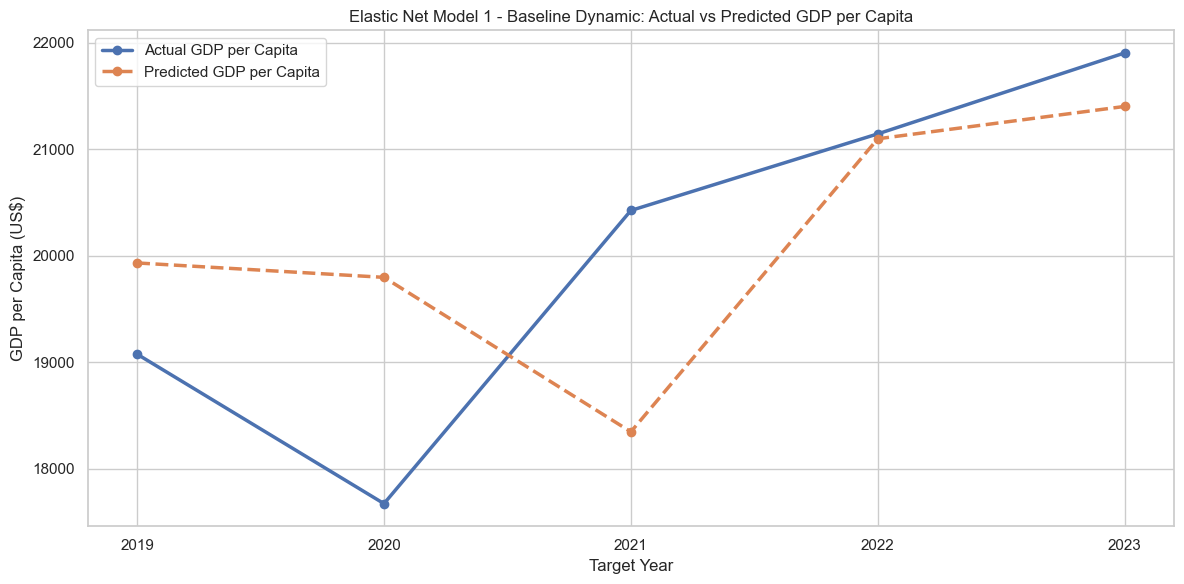

Saved:
- /Users/tonytony/Final Project/Data/Cleaned/gdp_elastic_net_model_1_dynamic_validation_search.csv
- /Users/tonytony/Final Project/Data/Cleaned/gdp_elastic_net_model_1_dynamic_metrics.csv
- /Users/tonytony/Final Project/Data/Cleaned/gdp_elastic_net_model_1_dynamic_train_predictions.csv
- /Users/tonytony/Final Project/Data/Cleaned/gdp_elastic_net_model_1_dynamic_test_predictions.csv
- /Users/tonytony/Final Project/Data/Cleaned/gdp_elastic_net_model_1_dynamic_yearly_summary.csv
- /Users/tonytony/Final Project/Data/Cleaned/gdp_elastic_net_model_1_dynamic_coefficients.csv
- /Users/tonytony/Final Project/Data/Cleaned/gdp_elastic_net_model_1_dynamic_region_metrics.csv


In [3]:
# Cell 3A - Elastic Net Model 1

elastic_net_model_1_result = run_elastic_net_spec(
    model_name="Elastic Net Model 1 - Baseline Dynamic",
    model_family="Regularized Linear ML",
    model_note="Elastic Net version of Model 1 using lag GDP, population, and life expectancy.",
    output_prefix="gdp_elastic_net_model_1_dynamic",
    usecols=[
        "country_name",
        "country_code",
        "wb_region",
        "year",
        "gdp_per_capita_usd",
        "log_gdp_per_capita",
        "population_total",
        "log_population_total",
        "life_expectancy_years",
        "target_log_gdp_next_year",
    ],
    numeric_features=[
        "log_gdp_per_capita",
        "log_population_total",
        "life_expectancy_years",
    ],
    categorical_features=[],
    make_year_trend=False,
)

Elastic Net Model 2 - Extended Dynamic
Sample shape: (4722, 13)
Train core rows: 3570
Validation rows: 339
Train full rows: 3909
Test rows: 813
Test target years: 2019 - 2023
Best alpha: 0.005
Best l1_ratio: 0.9


,model,alpha,l1_ratio,n_valid,valid_MAE_level,valid_RMSE_level,valid_MAPE_level,valid_R2_level,valid_MAE_log,valid_RMSE_log,valid_MAPE_log,valid_R2_log
0,Elastic Net Model 2 - Extended Dynamic,0.0050,0.9000,339,751.3073,"1,527.3046",5.5036,0.9946,0.0556,0.0905,0.6644,0.9960
1,Elastic Net Model 2 - Extended Dynamic,0.0050,0.7000,339,757.4537,"1,544.7576",5.5379,0.9944,0.0560,0.0908,0.6687,0.9960
2,Elastic Net Model 2 - Extended Dynamic,0.0050,0.5000,339,763.4815,"1,557.6268",5.5651,0.9943,0.0563,0.0911,0.6723,0.9959
3,Elastic Net Model 2 - Extended Dynamic,0.0050,0.3000,339,771.0114,"1,573.5530",5.6002,0.9942,0.0566,0.0914,0.6769,0.9959
4,Elastic Net Model 2 - Extended Dynamic,0.0010,0.9000,339,817.5328,"1,615.5769",5.7878,0.9939,0.0589,0.0924,0.6987,0.9958
5,Elastic Net Model 2 - Extended Dynamic,0.0010,0.7000,339,823.0277,"1,625.9096",5.8079,0.9938,0.0592,0.0926,0.7011,0.9958
6,Elastic Net Model 2 - Extended Dynamic,0.0050,0.1000,339,799.5648,"1,630.7648",5.6952,0.9938,0.0577,0.0922,0.6880,0.9958
7,Elastic Net Model 2 - Extended Dynamic,0.0010,0.5000,339,828.5163,"1,636.2989",5.8279,0.9937,0.0594,0.0927,0.7035,0.9958
8,Elastic Net Model 2 - Extended Dynamic,0.0005,0.9000,339,834.2004,"1,641.0220",5.8574,0.9937,0.0597,0.0929,0.7070,0.9958
9,Elastic Net Model 2 - Extended Dynamic,0.0005,0.7000,339,836.9410,"1,646.2307",5.8674,0.9937,0.0598,0.0930,0.7082,0.9958


,model,model_family,split,scale,n_obs,alpha,l1_ratio,MAE,RMSE,MAPE_pct,R_squared
0,Elastic Net Model 2 - Extended Dynamic,Regularized Linear ML,train,level_gdp_usd,3909,0.0050,0.9000,940.1299,"2,179.0237",9.0176,0.9840
1,Elastic Net Model 2 - Extended Dynamic,Regularized Linear ML,train,log_gdp,3909,0.0050,0.9000,0.0885,0.1306,1.1232,0.9930
2,Elastic Net Model 2 - Extended Dynamic,Regularized Linear ML,test,level_gdp_usd,813,0.0050,0.9000,"1,486.9078","3,468.6213",9.1557,0.9767
3,Elastic Net Model 2 - Extended Dynamic,Regularized Linear ML,test,log_gdp,813,0.0050,0.9000,0.0894,0.1236,1.0297,0.9924


,term,coefficient,abs_coefficient
0,log_gdp_per_capita,1.5316,1.5316
1,life_expectancy_years,0.0208,0.0208
2,log_population_total,-0.0000,0.0000
3,inflation_pct_clean,0.0000,0.0000
4,unemployment_pct_clean,0.0000,0.0000
5,internet_users_pct_clean,0.0000,0.0000


,target_year,n_obs,actual_mean_gdp,predicted_mean_gdp,pred_to_actual_ratio,mean_absolute_percentage_error_pct
0,2019,166,"15,698.9605","16,343.5832",1.0411,5.9709
1,2020,166,"14,549.3612","16,130.0415",1.1086,13.9297
2,2021,162,"17,155.0981","15,159.8329",0.8837,9.7775
3,2022,160,"18,048.6179","17,729.2406",0.9823,8.1779
4,2023,159,"18,914.0876","18,541.8839",0.9803,7.8472


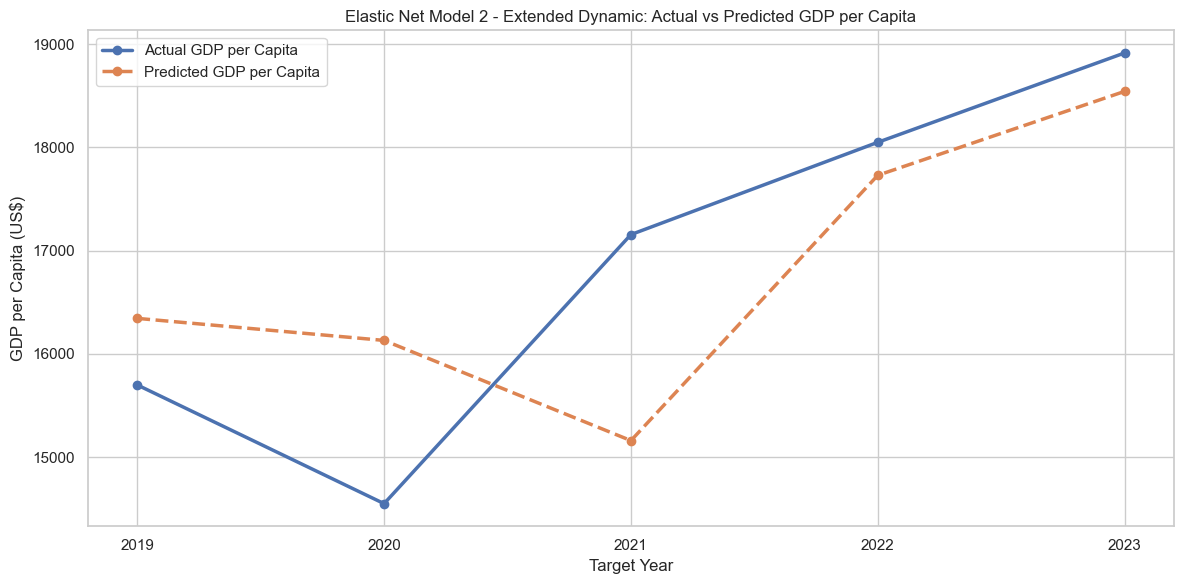

Saved:
- /Users/tonytony/Final Project/Data/Cleaned/gdp_elastic_net_model_2_dynamic_validation_search.csv
- /Users/tonytony/Final Project/Data/Cleaned/gdp_elastic_net_model_2_dynamic_metrics.csv
- /Users/tonytony/Final Project/Data/Cleaned/gdp_elastic_net_model_2_dynamic_train_predictions.csv
- /Users/tonytony/Final Project/Data/Cleaned/gdp_elastic_net_model_2_dynamic_test_predictions.csv
- /Users/tonytony/Final Project/Data/Cleaned/gdp_elastic_net_model_2_dynamic_yearly_summary.csv
- /Users/tonytony/Final Project/Data/Cleaned/gdp_elastic_net_model_2_dynamic_coefficients.csv
- /Users/tonytony/Final Project/Data/Cleaned/gdp_elastic_net_model_2_dynamic_region_metrics.csv


In [4]:
# Cell 3B - Elastic Net Model 2

elastic_net_model_2_result = run_elastic_net_spec(
    model_name="Elastic Net Model 2 - Extended Dynamic",
    model_family="Regularized Linear ML",
    model_note="Elastic Net version of Model 2 using lag GDP, population, life expectancy, inflation, unemployment, and internet usage.",
    output_prefix="gdp_elastic_net_model_2_dynamic",
    usecols=[
        "country_name",
        "country_code",
        "wb_region",
        "year",
        "gdp_per_capita_usd",
        "log_gdp_per_capita",
        "population_total",
        "log_population_total",
        "life_expectancy_years",
        "inflation_pct_clean",
        "unemployment_pct_clean",
        "internet_users_pct_clean",
        "target_log_gdp_next_year",
    ],
    numeric_features=[
        "log_gdp_per_capita",
        "log_population_total",
        "life_expectancy_years",
        "inflation_pct_clean",
        "unemployment_pct_clean",
        "internet_users_pct_clean",
    ],
    categorical_features=[],
    make_year_trend=False,
)

Elastic Net Model 3 - Full Dynamic
Sample shape: (4722, 16)
Train core rows: 3570
Validation rows: 339
Train full rows: 3909
Test rows: 813
Test target years: 2019 - 2023
Best alpha: 0.005
Best l1_ratio: 0.9


,model,alpha,l1_ratio,n_valid,valid_MAE_level,valid_RMSE_level,valid_MAPE_level,valid_R2_level,valid_MAE_log,valid_RMSE_log,valid_MAPE_log,valid_R2_log
0,Elastic Net Model 3 - Full Dynamic,0.0050,0.9000,339,820.4080,"1,652.8229",5.7093,0.9936,0.0580,0.0919,0.6879,0.9959
1,Elastic Net Model 3 - Full Dynamic,0.0100,0.9000,339,816.9962,"1,673.8533",5.6956,0.9935,0.0575,0.0917,0.6845,0.9959
2,Elastic Net Model 3 - Full Dynamic,0.0010,0.9000,339,860.1918,"1,690.5137",5.9045,0.9933,0.0604,0.0931,0.7128,0.9958
3,Elastic Net Model 3 - Full Dynamic,0.0050,0.7000,339,841.2034,"1,695.8481",5.7839,0.9933,0.0589,0.0924,0.6970,0.9958
4,Elastic Net Model 3 - Full Dynamic,0.0010,0.7000,339,865.5823,"1,699.0993",5.9260,0.9933,0.0606,0.0932,0.7154,0.9957
5,Elastic Net Model 3 - Full Dynamic,0.0010,0.5000,339,871.7472,"1,709.0374",5.9470,0.9932,0.0608,0.0934,0.7179,0.9957
6,Elastic Net Model 3 - Full Dynamic,0.0005,0.9000,339,875.2713,"1,709.2100",5.9712,0.9932,0.0611,0.0936,0.7207,0.9957
7,Elastic Net Model 3 - Full Dynamic,0.0005,0.7000,339,878.1139,"1,713.9570",5.9811,0.9931,0.0612,0.0936,0.7219,0.9957
8,Elastic Net Model 3 - Full Dynamic,0.0005,0.5000,339,879.7614,"1,716.5540",5.9874,0.9931,0.0613,0.0937,0.7227,0.9957
9,Elastic Net Model 3 - Full Dynamic,0.0010,0.3000,339,877.3582,"1,718.3037",5.9663,0.9931,0.0611,0.0936,0.7202,0.9957


,model,model_family,split,scale,n_obs,alpha,l1_ratio,MAE,RMSE,MAPE_pct,R_squared
0,Elastic Net Model 3 - Full Dynamic,Regularized Linear ML,train,level_gdp_usd,3909,0.0050,0.9000,925.0467,"2,136.1954",8.8472,0.9847
1,Elastic Net Model 3 - Full Dynamic,Regularized Linear ML,train,log_gdp,3909,0.0050,0.9000,0.0870,0.1282,1.1022,0.9932
2,Elastic Net Model 3 - Full Dynamic,Regularized Linear ML,test,level_gdp_usd,813,0.0050,0.9000,"1,487.8599","3,476.2812",9.1411,0.9766
3,Elastic Net Model 3 - Full Dynamic,Regularized Linear ML,test,log_gdp,813,0.0050,0.9000,0.0894,0.1237,1.0295,0.9924


,term,coefficient,abs_coefficient
0,log_gdp_per_capita,1.5321,1.5321
1,life_expectancy_years,0.0195,0.0195
2,asian_financial_crisis_9798,-0.0188,0.0188
3,global_financial_crisis_0809,-0.0075,0.0075
4,year_trend,-0.0047,0.0047
5,log_population_total,-0.0000,0.0000
6,inflation_pct_clean,0.0000,0.0000
7,unemployment_pct_clean,0.0000,0.0000
8,internet_users_pct_clean,-0.0000,0.0000
9,wb_region_East Asia & Pacific,0.0000,0.0000


,target_year,n_obs,actual_mean_gdp,predicted_mean_gdp,pred_to_actual_ratio,mean_absolute_percentage_error_pct
0,2019,166,"15,698.9605","16,323.7066",1.0398,5.9173
1,2020,166,"14,549.3612","16,099.2676",1.1065,13.7802
2,2021,162,"17,155.0981","15,121.7619",0.8815,9.8995
3,2022,160,"18,048.6179","17,674.7900",0.9793,8.1714
4,2023,159,"18,914.0876","18,471.7069",0.9766,7.8668


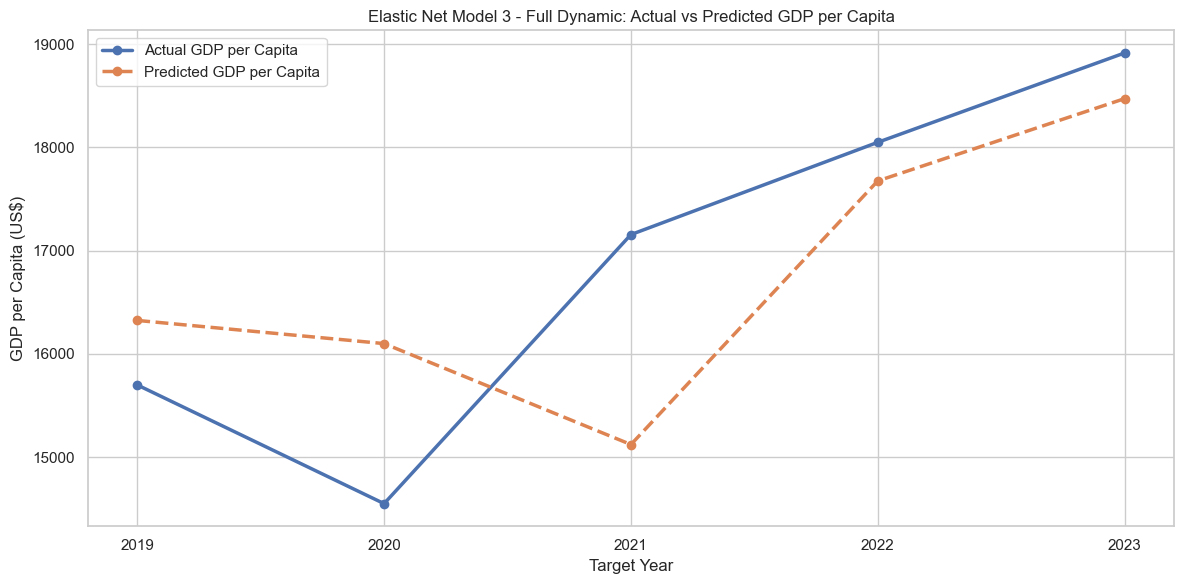

Saved:
- /Users/tonytony/Final Project/Data/Cleaned/gdp_elastic_net_model_3_dynamic_validation_search.csv
- /Users/tonytony/Final Project/Data/Cleaned/gdp_elastic_net_model_3_dynamic_metrics.csv
- /Users/tonytony/Final Project/Data/Cleaned/gdp_elastic_net_model_3_dynamic_train_predictions.csv
- /Users/tonytony/Final Project/Data/Cleaned/gdp_elastic_net_model_3_dynamic_test_predictions.csv
- /Users/tonytony/Final Project/Data/Cleaned/gdp_elastic_net_model_3_dynamic_yearly_summary.csv
- /Users/tonytony/Final Project/Data/Cleaned/gdp_elastic_net_model_3_dynamic_coefficients.csv
- /Users/tonytony/Final Project/Data/Cleaned/gdp_elastic_net_model_3_dynamic_region_metrics.csv


In [5]:
# Cell 3C - Elastic Net Model 3

elastic_net_model_3_result = run_elastic_net_spec(
    model_name="Elastic Net Model 3 - Full Dynamic",
    model_family="Regularized Linear ML",
    model_note="Elastic Net version of Model 3 using lag GDP, extra drivers, event dummies, region effects, and year trend.",
    output_prefix="gdp_elastic_net_model_3_dynamic",
    usecols=[
        "country_name",
        "country_code",
        "wb_region",
        "year",
        "gdp_per_capita_usd",
        "log_gdp_per_capita",
        "population_total",
        "log_population_total",
        "life_expectancy_years",
        "inflation_pct_clean",
        "unemployment_pct_clean",
        "internet_users_pct_clean",
        "asian_financial_crisis_9798",
        "global_financial_crisis_0809",
        "target_log_gdp_next_year",
    ],
    numeric_features=[
        "log_gdp_per_capita",
        "log_population_total",
        "life_expectancy_years",
        "inflation_pct_clean",
        "unemployment_pct_clean",
        "internet_users_pct_clean",
        "asian_financial_crisis_9798",
        "global_financial_crisis_0809",
        "year_trend",
    ],
    categorical_features=[
        "wb_region",
    ],
    make_year_trend=True,
)

,model,model_family,split,scale,n_obs,alpha,l1_ratio,MAE,RMSE,MAPE_pct,R_squared
0,Elastic Net Model 2 - Extended Dynamic,Regularized Linear ML,test,level_gdp_usd,813,0.0050,0.9000,"1,486.9078","3,468.6213",9.1557,0.9767
1,Elastic Net Model 3 - Full Dynamic,Regularized Linear ML,test,level_gdp_usd,813,0.0050,0.9000,"1,487.8599","3,476.2812",9.1411,0.9766
2,Elastic Net Model 1 - Baseline Dynamic,Regularized Linear ML,test,level_gdp_usd,1042,0.0005,0.9000,"1,702.1639","3,977.3740",9.3014,0.9821


/var/folders/7n/3748sj1972d585qn1zk46ln00000gn/T/ipykernel_50901/3626462469.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=elastic_net_test_compare_df, x="model", y="MAE", palette="Blues_r")
/var/folders/7n/3748sj1972d585qn1zk46ln00000gn/T/ipykernel_50901/3626462469.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=elastic_net_test_compare_df, x="model", y="RMSE", palette="Greens_r")
/var/folders/7n/3748sj1972d585qn1zk46ln00000gn/T/ipykernel_50901/3626462469.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=elastic

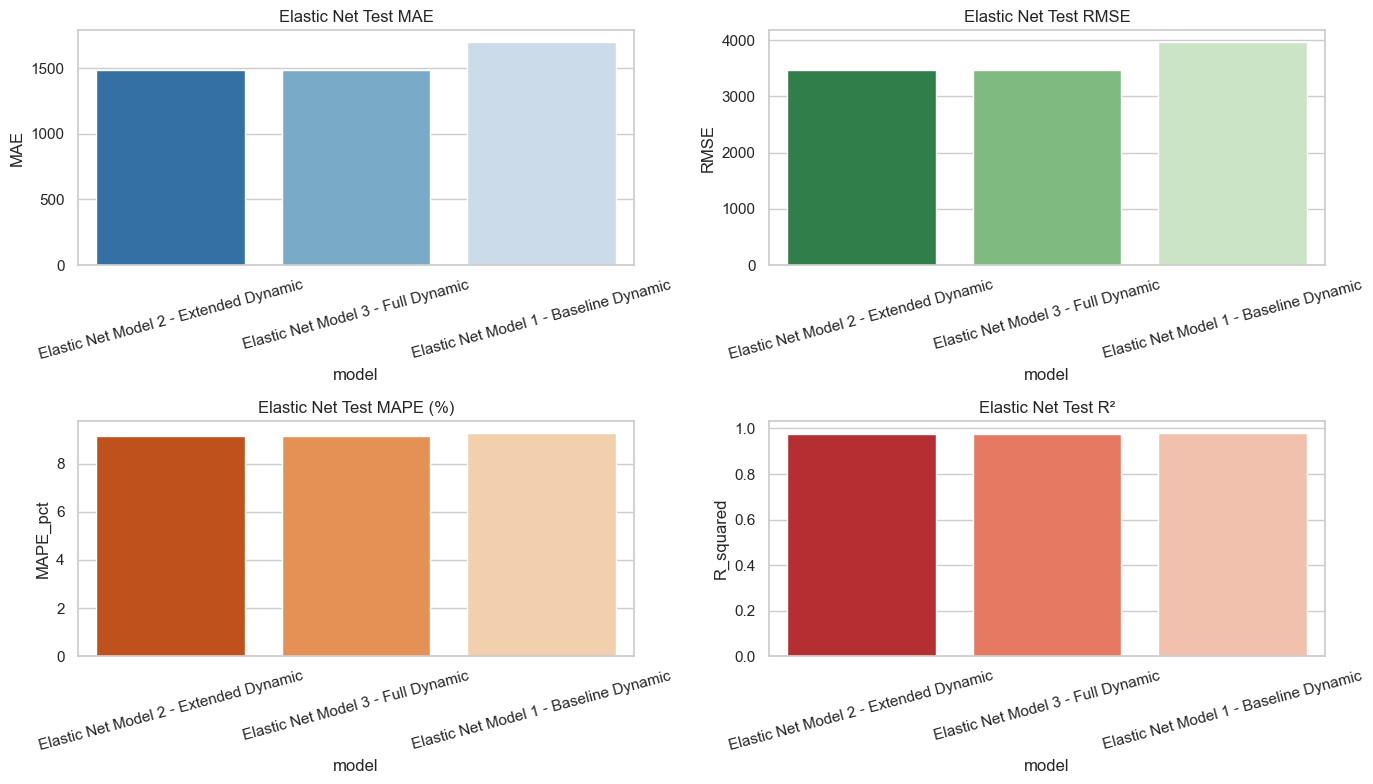

Saved:
- /Users/tonytony/Final Project/Data/Cleaned/gdp_elastic_net_models_1_2_3_compare.csv


In [6]:
# Cell 4 - Compare Elastic Net Model 1 / 2 / 3

elastic_net_compare_df = pd.concat(
    [
        elastic_net_model_1_result["metrics_df"],
        elastic_net_model_2_result["metrics_df"],
        elastic_net_model_3_result["metrics_df"],
    ],
    ignore_index=True,
)

elastic_net_test_compare_df = (
    elastic_net_compare_df[
        (elastic_net_compare_df["split"] == "test")
        & (elastic_net_compare_df["scale"] == "level_gdp_usd")
    ]
    .sort_values(["RMSE", "MAPE_pct", "MAE"])
    .reset_index(drop=True)
)

display(elastic_net_test_compare_df)

plt.figure(figsize=(14, 8))

plt.subplot(2, 2, 1)
sns.barplot(data=elastic_net_test_compare_df, x="model", y="MAE", palette="Blues_r")
plt.title("Elastic Net Test MAE")
plt.xticks(rotation=15)

plt.subplot(2, 2, 2)
sns.barplot(data=elastic_net_test_compare_df, x="model", y="RMSE", palette="Greens_r")
plt.title("Elastic Net Test RMSE")
plt.xticks(rotation=15)

plt.subplot(2, 2, 3)
sns.barplot(data=elastic_net_test_compare_df, x="model", y="MAPE_pct", palette="Oranges_r")
plt.title("Elastic Net Test MAPE (%)")
plt.xticks(rotation=15)

plt.subplot(2, 2, 4)
sns.barplot(data=elastic_net_test_compare_df, x="model", y="R_squared", palette="Reds_r")
plt.title("Elastic Net Test R²")
plt.xticks(rotation=15)

plt.tight_layout()
show_or_close_plot()

elastic_net_compare_path = OUTPUT_DIR / "gdp_elastic_net_models_1_2_3_compare.csv"
elastic_net_test_compare_df.to_csv(elastic_net_compare_path, index=False)

print("Saved:")
print("-", elastic_net_compare_path)